Employee Dataset | **Classification**

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# Load and Explore the Dataset

In [ ]:
df = pd.read_csv('/content/Employee.csv')

In [ ]:
# Display first 5 rows
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [ ]:
df.shape # The dataset contains 4653 rows and 9 columns.

(4653, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [ ]:
# Missing values check
df.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [ ]:
df.duplicated().sum()

np.int64(1889)

> There are 1,889 duplicate entries. However, since the dataset lacks a unique Employee ID, it is statistically probable that multiple employees share identical profiles (age, city, tier, etc.). I will proceed without removing these duplicates to preserve the data distribution.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
JoiningYear,4653.0,2015.062970,1.863377,2012.0,2013.0,2015.0,2017.0,2018.0
PaymentTier,4653.0,2.698259,0.561435,1.0,3.0,3.0,3.0,3.0
Age,4653.0,29.393295,4.826087,22.0,26.0,28.0,32.0,41.0
ExperienceInCurrentDomain,4653.0,2.905652,1.558240,0.0,2.0,3.0,4.0,7.0
LeaveOrNot,4653.0,0.343864,0.475047,0.0,0.0,0.0,1.0,1.0


> No missing values detected. The average age is 29, and the average experience in the current domain is approximately 3 years.

In [ ]:
df["LeaveOrNot"].value_counts()

,count
LeaveOrNot,
0,3053
1,1600


In [ ]:
# 3053 employees stayed, while 1600 left.

# Data Visualization

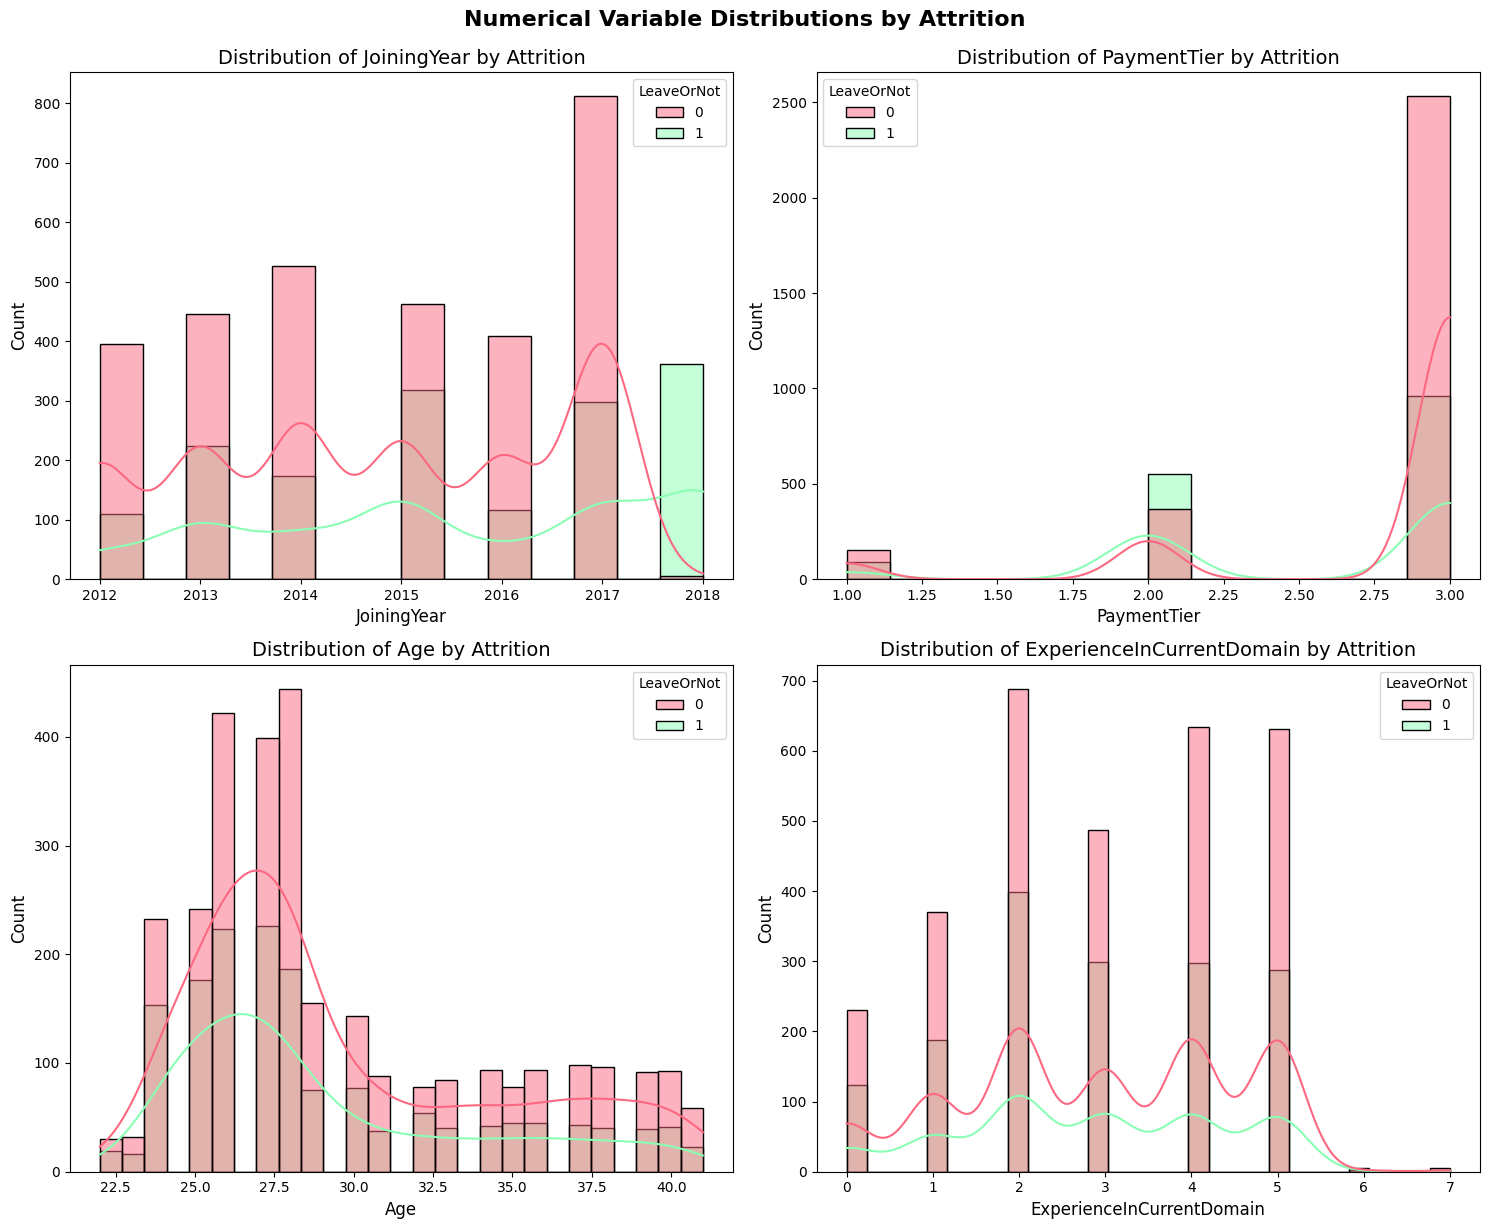

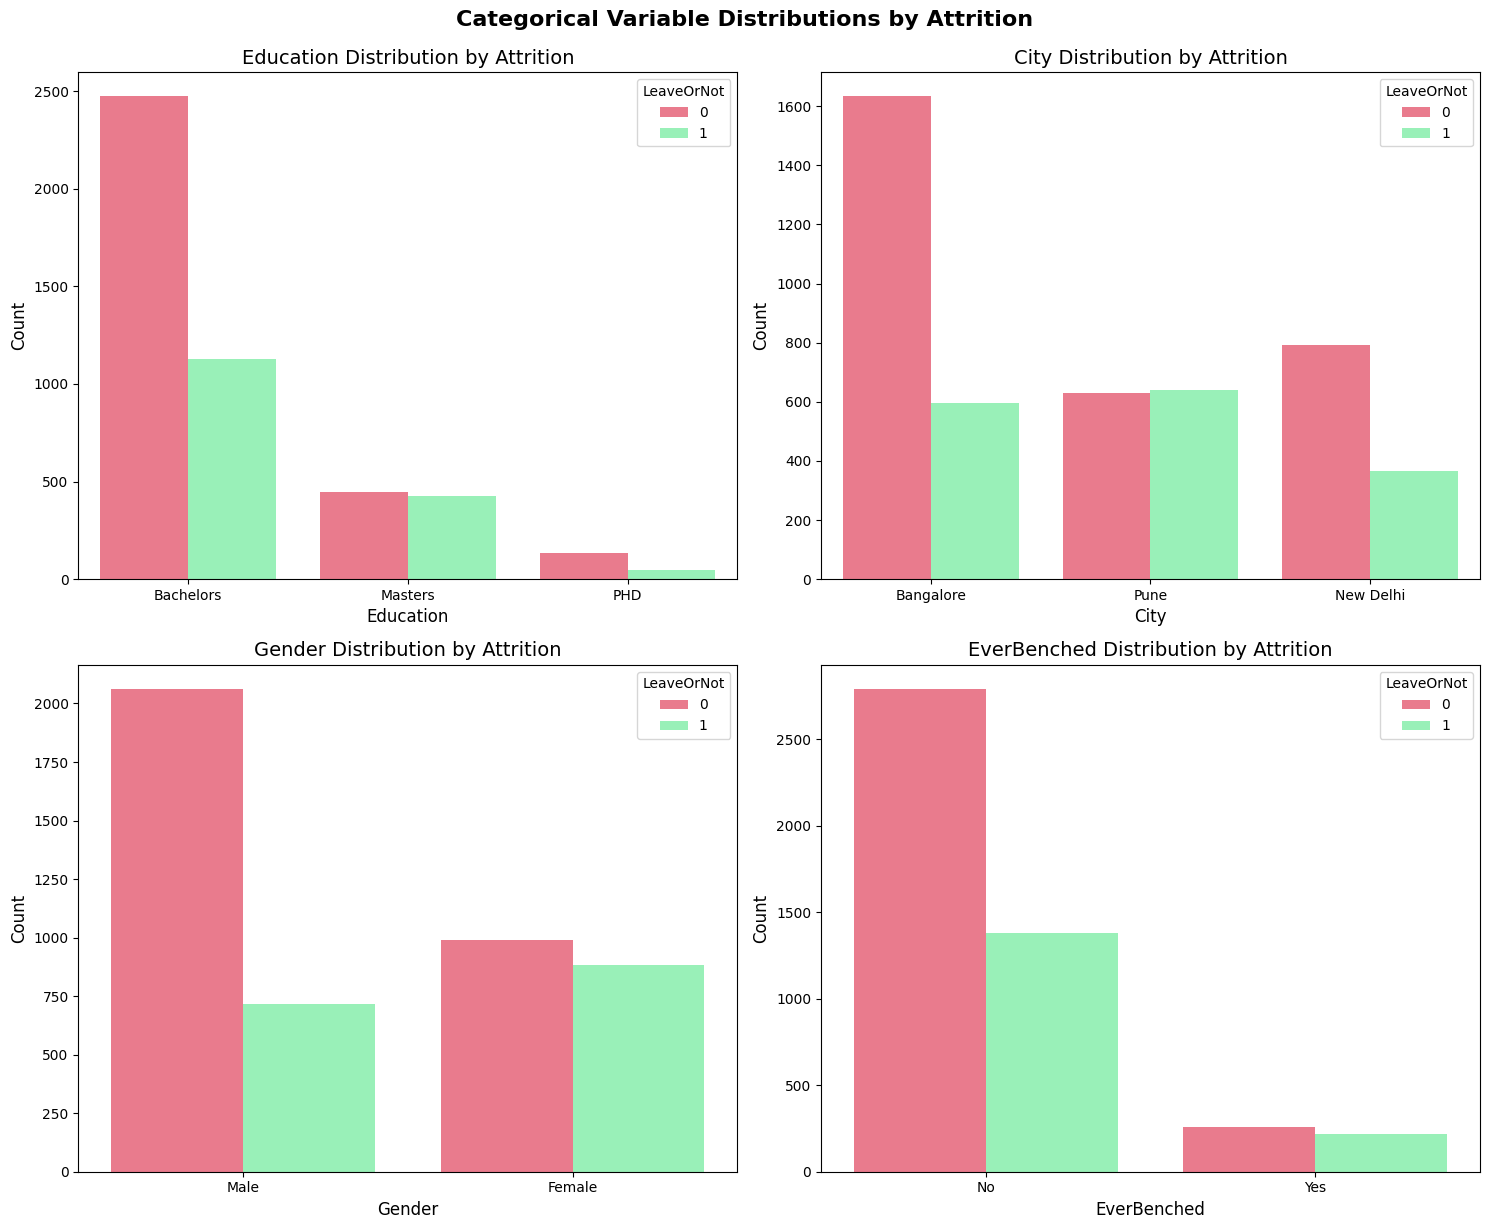

In [ ]:
# Identify numerical and categorical columns (excluding the target 'LeaveOrNot')
numerical_cols = ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']
categorical_cols = ['Education', 'City', 'Gender', 'EverBenched']

fig_num, axes_num = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes_num = axes_num.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='LeaveOrNot', kde=True, ax=axes_num[i], palette={0: '#fc6881', 1: '#8affb4'})
    axes_num[i].set_title(f'Distribution of {col} by Attrition', fontsize=14)
    axes_num[i].set_xlabel(col, fontsize=12)
    axes_num[i].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.suptitle('Numerical Variable Distributions by Attrition', y=1.02, fontsize=16, fontweight='bold')
plt.show()

fig_cat, axes_cat = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes_cat = axes_cat.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='LeaveOrNot', ax=axes_cat[i], palette={0: '#fc6881', 1: '#8affb4'})
    axes_cat[i].set_title(f'{col} Distribution by Attrition', fontsize=14)
    axes_cat[i].set_xlabel(col, fontsize=12)
    axes_cat[i].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.suptitle('Categorical Variable Distributions by Attrition', y=1.02, fontsize=16, fontweight='bold')
plt.show()

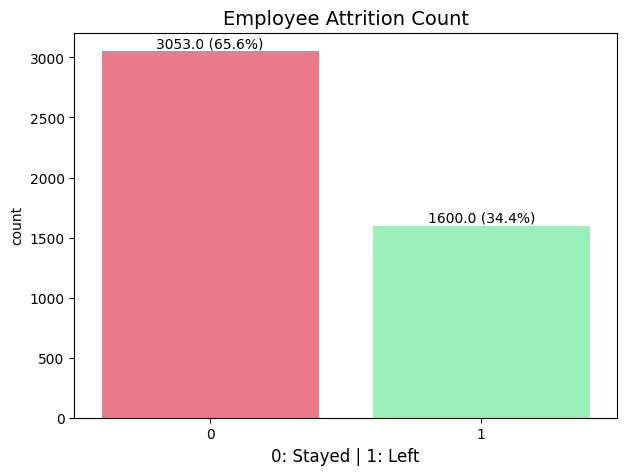

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='LeaveOrNot', data=df, palette=['#fc6881', '#8affb4'])
plt.title('Employee Attrition Count', fontsize=14)
plt.xlabel('0: Stayed | 1: Left', fontsize=12)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 30,
            f'{height} ({100 * height/total:.1f}%)', ha='center')
plt.show()

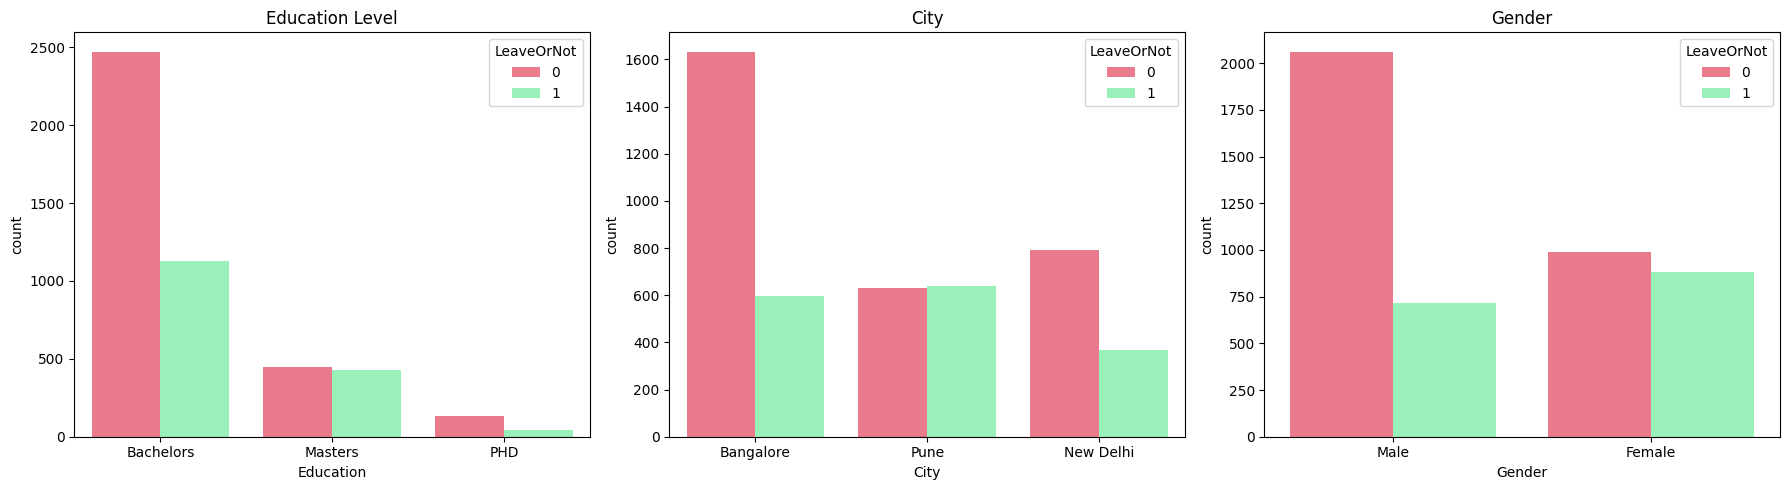

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Education
sns.countplot(x='Education', hue='LeaveOrNot', data=df, ax=axes[0], palette=['#fc6881', '#8affb4'])
axes[0].set_title('Education Level')

# City
sns.countplot(x='City', hue='LeaveOrNot', data=df, ax=axes[1], palette=['#fc6881', '#8affb4'])
axes[1].set_title('City')

# Gender
sns.countplot(x='Gender', hue='LeaveOrNot', data=df, ax=axes[2], palette=['#fc6881', '#8affb4'])
axes[2].set_title('Gender')

plt.tight_layout()
plt.show()

> **Key Observations:**
* **Education**: Most employees hold a Bachelor's degree. However, Master's degree holders show a notably higher attrition rate (nearly 50%).
* **City**: Pune has a significantly higher attrition rate compared to Bangalore and New Delhi.
* **Gender**: Female employees exhibit a higher likelihood of leaving compared to male employees.

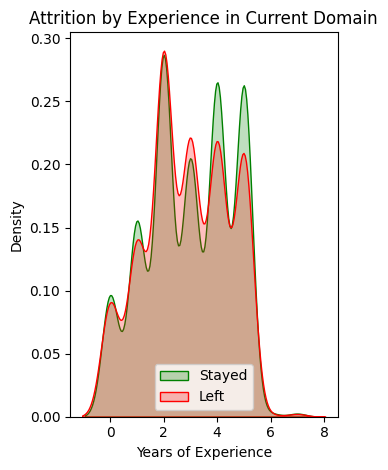

In [ ]:
plt.subplot(1, 2, 2)
sns.kdeplot(data=df[df['LeaveOrNot'] == 0]['ExperienceInCurrentDomain'], label='Stayed', shade=True, color='green')
sns.kdeplot(data=df[df['LeaveOrNot'] == 1]['ExperienceInCurrentDomain'], label='Left', shade=True, color='red')
plt.title('Attrition by Experience in Current Domain')
plt.xlabel('Years of Experience')
plt.legend()

plt.tight_layout()
plt.show()

> Employees with exactly 3 years of experience in their current domain appear to be at a higher risk of attrition.

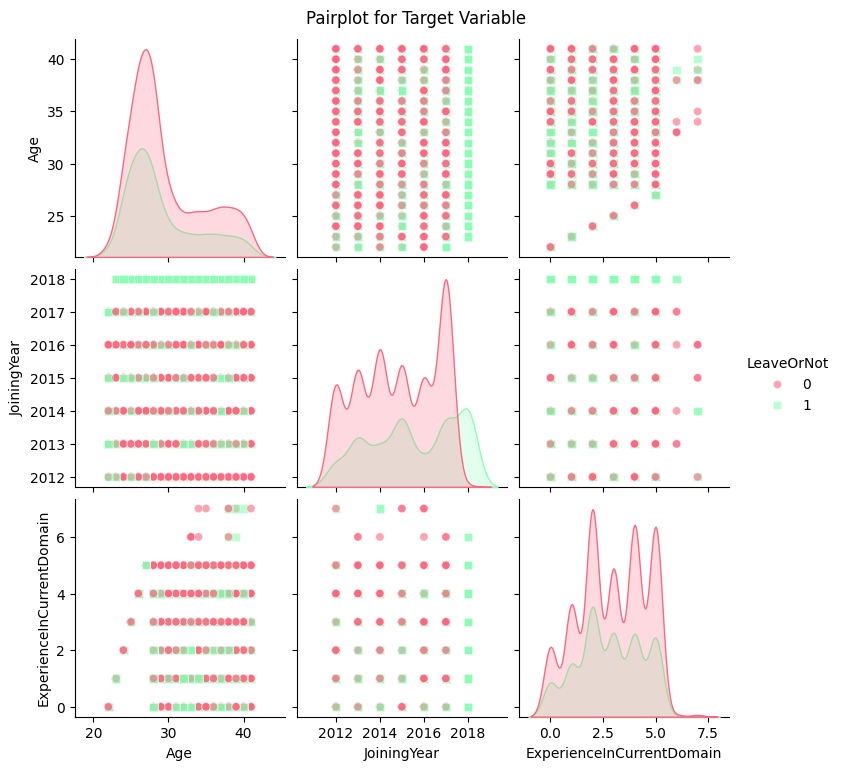

In [ ]:
variables = ['Age', 'JoiningYear', 'ExperienceInCurrentDomain', 'LeaveOrNot']
sns.pairplot(df[variables], hue='LeaveOrNot', palette=['#fc6881', '#8affb4'], markers=['o', 's'], plot_kws={'alpha':0.6})
plt.suptitle('Pairplot for Target Variable', y=1.02)
plt.show()

# Outlier Analysis

--Outlier Report--
Outliers in the Age Column: 0
Outliers in the Experience  Column: 0


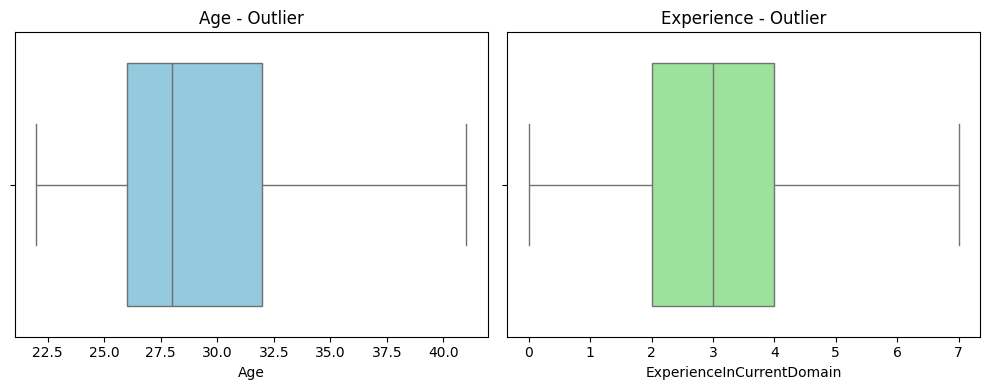

In [ ]:
# Checking for Outliers in the Age Column Using the IQR Method
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_age = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

# Checking for Outliers in the Experience Column Using the IQR Method
Q1_exp = df['ExperienceInCurrentDomain'].quantile(0.25)
Q3_exp = df['ExperienceInCurrentDomain'].quantile(0.75)
IQR_exp = Q3_exp - Q1_exp
lower_bound_exp = Q1_exp - 1.5 * IQR_exp
upper_bound_exp = Q3_exp + 1.5 * IQR_exp

outliers_exp = df[(df['ExperienceInCurrentDomain'] < lower_bound_exp) | (df['ExperienceInCurrentDomain'] > upper_bound_exp)]

print("--Outlier Report--")
print(f"Outliers in the Age Column: {len(outliers_age)}")
print(f"Outliers in the Experience  Column: {len(outliers_exp)}")

# Let's also show it using a box plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Age - Outlier')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['ExperienceInCurrentDomain'], color='lightgreen')
plt.title('Experience - Outlier')

plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
# Encode categorical variables using LabelEncoder
cat_features = ['Education', 'City', 'Gender', 'EverBenched']
le = LabelEncoder()
df_processed = df.copy()

for col in cat_features:
    df_processed[col] = le.fit_transform(df_processed[col])

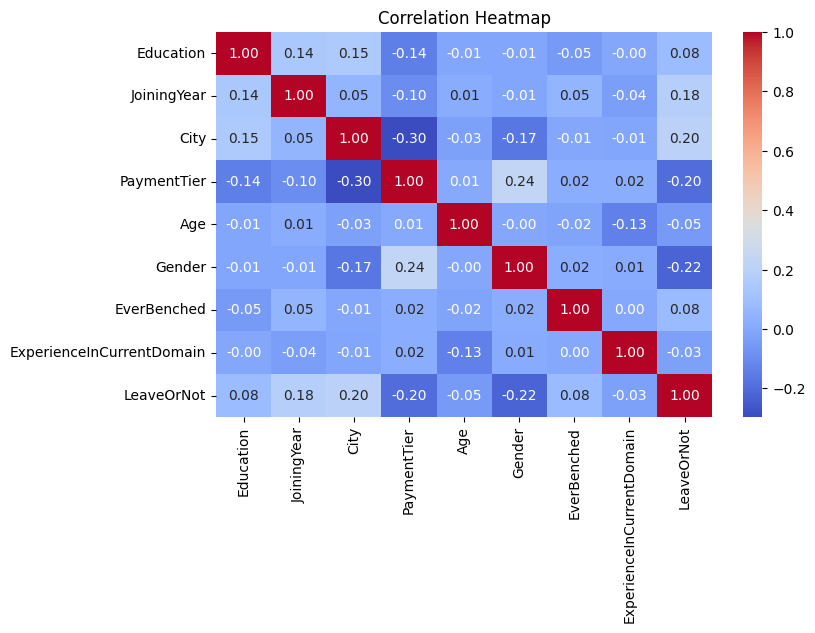

In [ ]:
# Correlation Matrix
plt.figure(figsize=(8,5))
sns.heatmap(df_processed.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df_processed.drop('LeaveOrNot', axis=1)
y = df_processed['LeaveOrNot']

In [ ]:
# Split data (80% Train / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 3722, Test size: 931


In [ ]:
# Feature Scaling (This is a critical step for SVM and Neural Network models. It sets the mean to 0 and the standard deviation to 1.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#We do not fit the model to the test data otherwise, a data leak will occur

# PCA (Principal Component Analysis)

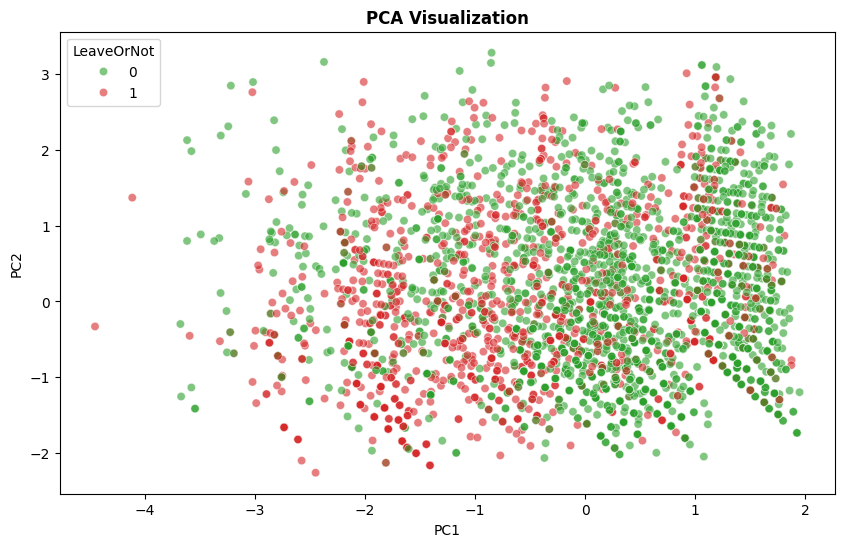

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['LeaveOrNot'] = y_train.values

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='LeaveOrNot', data=pca_df, palette={0: '#2ca02c', 1: '#d62728'}, alpha=0.6)
plt.title('PCA Visualization', fontweight='bold')
plt.show()

> We reduced our 8-variable dataset to two dimensions using PCA while preserving the variance.

> The PCA visualization reveals a complex, non-linear structure where classes are significantly overlapping, suggesting that simple linear models may underperform.

# Modeling
### Logistic Regression

Best Params: {'C': 0.1}
Accuracy: 0.7068
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       611
           1       0.62      0.38      0.47       320

    accuracy                           0.71       931
   macro avg       0.67      0.63      0.63       931
weighted avg       0.69      0.71      0.69       931



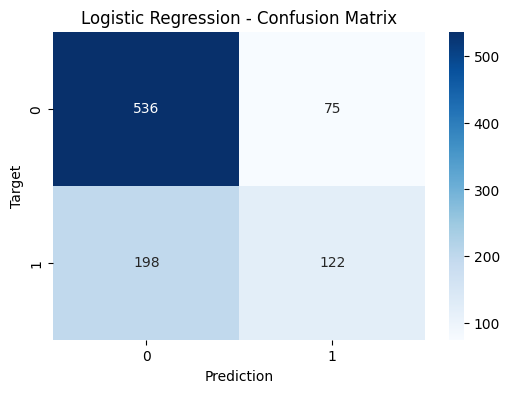

In [ ]:
log_param_grid = {'C': [0.01, 0.1, 1, 10]}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_param_grid, cv=5)
log_grid.fit(X_train_scaled, y_train)

log_best = log_grid.best_estimator_
y_pred_log = log_best.predict(X_test_scaled)

print(f'Best Params: {log_grid.best_params_}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_log):.4f}')
print(classification_report(y_test, y_pred_log))

#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.show()

> Logistic Regression showed suboptimal performance because employee turnover had a complex structure, as we saw in the PCA analysis. We need ensemble or non-linear models to capture the underlying complexity.

### SVM (Support Vector Machine)

Best Params: {'C': 10, 'kernel': 'rbf'}
Accuracy: %85.82

F1 Score: %75.82

Precision: %91.59

Recall: %64.69

              precision    recall  f1-score   support

           0      0.840     0.969     0.900       611
           1      0.916     0.647     0.758       320

    accuracy                          0.858       931
   macro avg      0.878     0.808     0.829       931
weighted avg      0.866     0.858     0.851       931



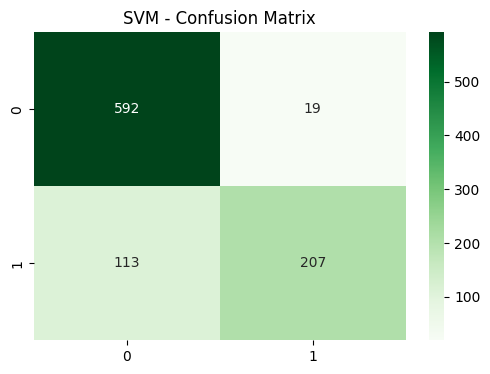

In [ ]:
#kernel: it enables the separation of nonlinear data by projecting it into high-dimensional spaces.
#we’ll try RBF and linear models.
#C:tolerance

svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=5)
svm_grid.fit(X_train_scaled, y_train)

svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

print(f"Best Params: {svm_grid.best_params_}")
print(f"Accuracy: %{accuracy_score(y_test, y_pred_svm)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test, y_pred_svm)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test, y_pred_svm)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test, y_pred_svm)*100:.2f}\n")

print(classification_report(y_test,y_pred_svm,digits=3))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title('SVM - Confusion Matrix')
plt.show()

> Support Vector Machine (SVM) with an RBF kernel significantly improved the classification accuracy to approximately 85%.

### Decision Tree

Best Params: {'max_depth': 10, 'min_samples_split': 5}
Accuracy: %82.92

F1 Score: %71.56

Precision: %83.68

Recall: %62.50

              precision    recall  f1-score   support

           0      0.827     0.936     0.878       611
           1      0.837     0.625     0.716       320

    accuracy                          0.829       931
   macro avg      0.832     0.781     0.797       931
weighted avg      0.830     0.829     0.822       931



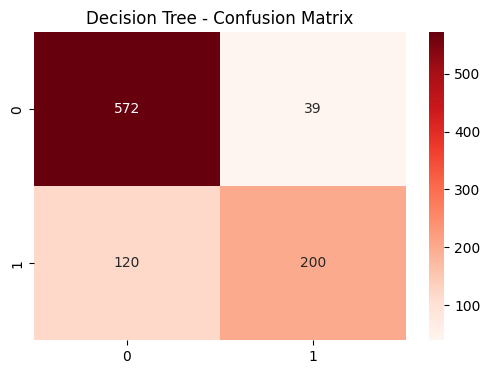

In [ ]:
#parameters
#max_depth: The maximum depth of the tree. If the depth increases too much, the model will overfit the training data.
#to prevent this, we limit the depth to between 5 and 10.
#min_samples_split: determines the minimum number of data points required in a branch.

dt_param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5)
dt_grid.fit(X_train_scaled, y_train)

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_scaled)

print(f"Best Params: {dt_grid.best_params_}")
print(f"Accuracy: %{accuracy_score(y_test, y_pred_dt)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test, y_pred_dt)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test, y_pred_dt)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test, y_pred_dt)*100:.2f}\n")

print(classification_report(y_test,y_pred_dt,digits=3))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Reds')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

### Random Forest

Best Params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
Accuracy Score: %87.11

F1 Score: %79.66

Precision: %87.04

Recall: %73.44

              precision    recall  f1-score   support

           0      0.871     0.943     0.906       611
           1      0.870     0.734     0.797       320

    accuracy                          0.871       931
   macro avg      0.871     0.839     0.851       931
weighted avg      0.871     0.871     0.868       931



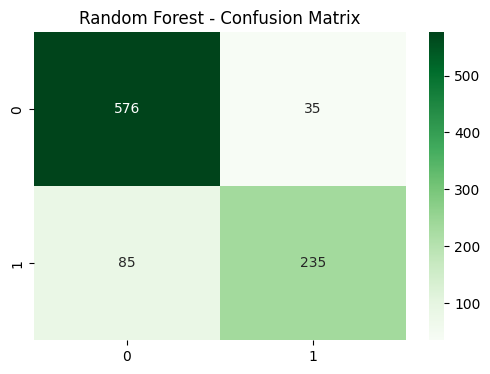

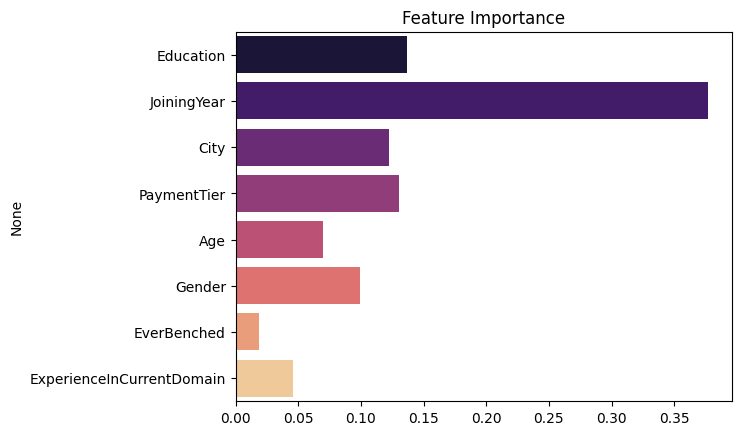

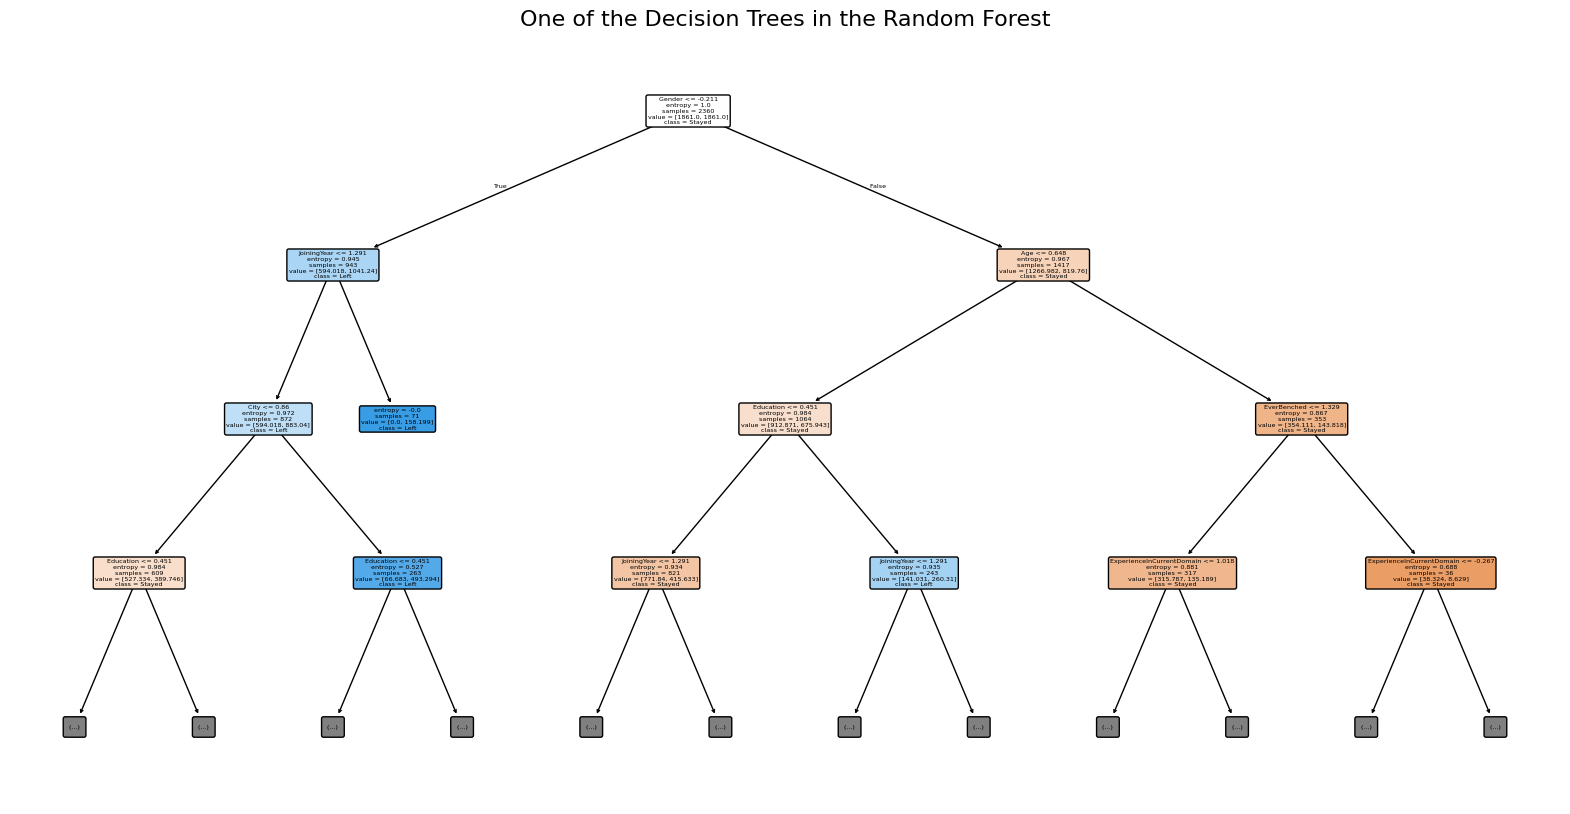

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import plot_tree
#parameters
#max_depth: the maximum depth of the tree. If the depth becomes too large, the model will overfit the training data.
#to prevent this, we limit the depth to between 5 and 10.
#n_estimators: the number of trees in the forest
#min_samples_split: the minimum number of samples required to split a branch
#min_samples_leaf: the minimum number of samples that must remain in a leaf node
#class_weight: a solution for class imbalance


rf_param_grid = {
    'n_estimators': [100, 250, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}
# Using RandomizedSearchCV for faster optimization due to long GridSearchCV runtimes
rf_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_param_grid, cv=5, n_iter=50, random_state=42)
rf_grid.fit(X_train_scaled, y_train)

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)

print(f"Best Params: {rf_grid.best_params_}")
print(f"Accuracy Score: %{accuracy_score(y_test, y_pred_rf)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test, y_pred_rf)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test, y_pred_rf)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test, y_pred_rf)*100:.2f}\n")

print(classification_report(y_test,y_pred_rf,digits=3))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

# Feature Importance
importances = rf_best.feature_importances_
features = X.columns
sns.barplot(x=importances, y=features, palette='magma')
plt.title('Feature Importance')
plt.show()

# Plotting one of the decision trees from the Random Forest
plt.figure(figsize=(20, 10))
plot_tree(rf_best.estimators_[0], feature_names=X.columns, class_names=['Stayed', 'Left'], filled=True, rounded=True, max_depth=3)
plt.title('One of the Decision Trees in the Random Forest', fontsize=16)
plt.show()

> After optimization, the Random Forest model emerged as the clear winner (in terms of accuracy and F1 score). When we examined the impact of the variables, the “joiningyear” variable was found to be highly influential, followed by “PaymentTier.”

### Gradient Boosting Model
> While Random Forest builds independent trees in parallel using the bagging method, Gradient Boosting constructs trees sequentially using the boosting approach. In this framework, each new tree focuses on minimizing the residuals of the previous tree and optimizing the gradient of the loss function.

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Accuracy Score: %84.53

F1 Score: %74.38

Precision: %86.36

Recall: %65.31

              precision    recall  f1-score   support

           0      0.839     0.946     0.889       611
           1      0.864     0.653     0.744       320

    accuracy                          0.845       931
   macro avg      0.851     0.800     0.817       931
weighted avg      0.847     0.845     0.839       931



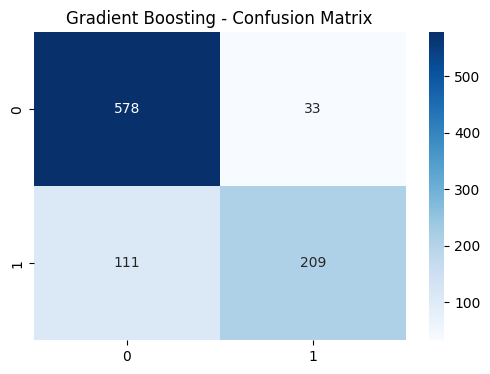

In [ ]:
#parameters
#learning_rate: the rate at which the model learns from errors. If too high, it may overshoot the target; if too low, it learns too slowly.

gb_param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7, 10]}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=5)
gb_grid.fit(X_train_scaled, y_train)

gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test_scaled)

print(f"Best Parameters: {gb_grid.best_params_}")
print(f"Accuracy Score: %{accuracy_score(y_test, y_pred_gb)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test, y_pred_gb)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test, y_pred_gb)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test, y_pred_gb)*100:.2f}\n")

print(classification_report(y_test, y_pred_gb, digits=3))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Blues')
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

### MLP (Neural Network)

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01, 'solver': 'adam'}
Accuracy Score: %85.39

F1 Score: %75.97

Precision: %87.40

Recall: %67.19

              precision    recall  f1-score   support

           0      0.847     0.949     0.895       611
           1      0.874     0.672     0.760       320

    accuracy                          0.854       931
   macro avg      0.860     0.811     0.827       931
weighted avg      0.856     0.854     0.849       931



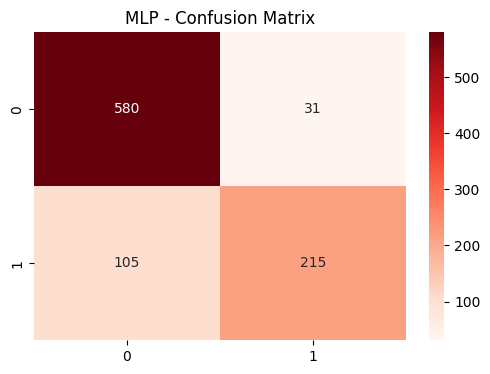

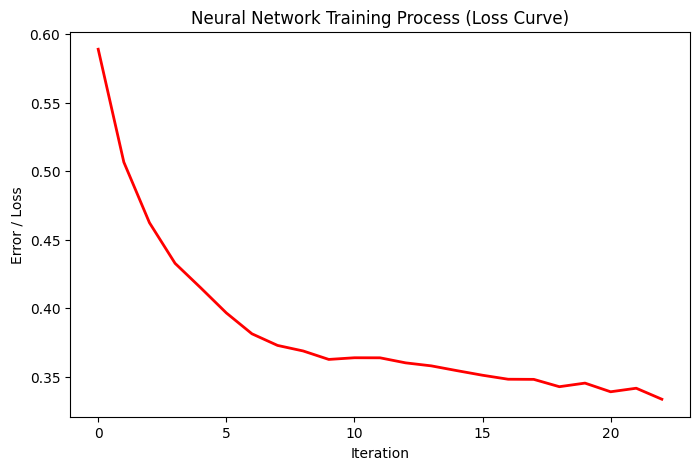

In [ ]:
# Parameters
# hidden_layer_sizes: determines the number of layers and neurons per layer.
# learning_rate_init: the step size for weight updates.
# solver: the algorithm used to minimize the error.
# alpha: regularization term to prevent overfitting.
# activation: activation function for the hidden layers.
# early_stopping: stops training when the model stops improving to prevent memorization.

mlp_param_grid = {'hidden_layer_sizes': [(32,), (64, 32)],
                  'alpha': [0.0001, 0.001],
                  'solver': ['adam', 'sgd'],
                  'learning_rate_init': [0.001, 0.005, 0.01],
                  'activation': ['relu', 'tanh']
                  }
mlp_grid = GridSearchCV(MLPClassifier(max_iter=500, early_stopping=True, random_state=42), mlp_param_grid, cv=5)
mlp_grid.fit(X_train_scaled, y_train)

mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)

print(f"Best Parameters: {mlp_grid.best_params_}")
print(f"Accuracy Score: %{accuracy_score(y_test, y_pred_mlp)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test, y_pred_mlp)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test, y_pred_mlp)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test, y_pred_mlp)*100:.2f}\n")

print(classification_report(y_test, y_pred_mlp, digits=3))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Reds')
plt.title('MLP - Confusion Matrix')
plt.show()

# Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(mlp_best.loss_curve_, color='red', linewidth=2)
plt.title('Neural Network Training Process (Loss Curve)')
plt.xlabel('Iteration')
plt.ylabel('Error / Loss')
plt.show()

### CatBoost Model

Best Parameters: {'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 10, 'auto_class_weights': 'Balanced'}
Accuracy Score: %86.25

F1 Score: %78.74

Precision: %84.04

Recall: %74.06

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       611
           1       0.84      0.74      0.79       320

    accuracy                           0.86       931
   macro avg       0.86      0.83      0.84       931
weighted avg       0.86      0.86      0.86       931



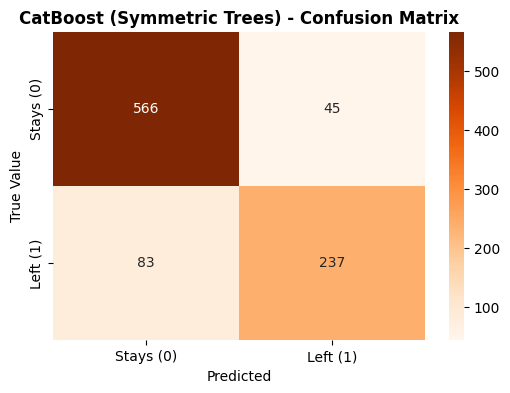

In [ ]:
from catboost import CatBoostClassifier # Import CatBoostClassifier
df_cat = pd.read_csv('Employee.csv')
X_cat = df_cat.drop('LeaveOrNot', axis=1)
y_cat = df_cat['LeaveOrNot']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

# it is crucial to tell CatBoost which columns are categorical
categorical_columns = ['Education', 'City', 'Gender', 'EverBenched']

cat_params = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [3, 5, 7],
    'auto_class_weights': ['Balanced']
}

cat_model = CatBoostClassifier(
    eval_metric='F1',
    random_seed=42,
    verbose=0
)

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_params,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

cat_search.fit(X_train_c, y_train_c, cat_features=categorical_columns)
best_cat = cat_search.best_estimator_
y_pred_cat = best_cat.predict(X_test_c)

print(f"Best Parameters: {cat_search.best_params_}")
print(f"Accuracy Score: %{accuracy_score(y_test_c, y_pred_cat)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test_c, y_pred_cat)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test_c, y_pred_cat)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test_c, y_pred_cat)*100:.2f}\n")

print(classification_report(y_test_c, y_pred_cat))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_c, y_pred_cat), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stays (0)', 'Left (1)'],
            yticklabels=['Stays (0)', 'Left (1)'])
plt.title('CatBoost (Symmetric Trees) - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True Value')
plt.show()

### LightGBM Model

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}
Accuracy Score: %83.78

F1 Score: %73.46

Precision: %83.94

Recall: %65.31

              precision    recall  f1-score   support

           0      0.837     0.935     0.883       611
           1      0.839     0.653     0.735       320

    accuracy                          0.838       931
   macro avg      0.838     0.794     0.809       931
weighted avg      0.838     0.838     0.832       931



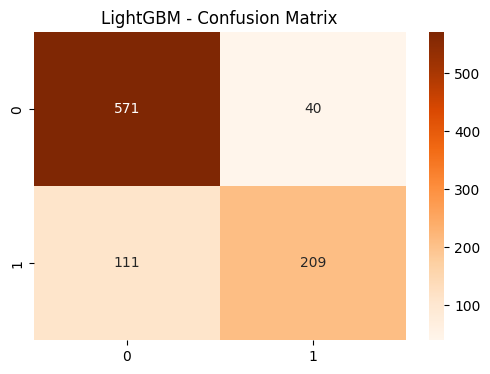

In [ ]:
import lightgbm as lgb

lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [5, 8, 10]
}

lgb_grid = GridSearchCV(lgb.LGBMClassifier(random_state=42, verbose=-1), lgb_param_grid, cv=5)
lgb_grid.fit(X_train_scaled, y_train)

lgb_best = lgb_grid.best_estimator_
y_pred_lgb = lgb_best.predict(X_test_scaled)

print(f"Best Parameters: {lgb_grid.best_params_}")
print(f"Accuracy Score: %{accuracy_score(y_test, y_pred_lgb)*100:.2f}\n")
print(f"F1 Score: %{f1_score(y_test, y_pred_lgb)*100:.2f}\n")
print(f"Precision: %{precision_score(y_test, y_pred_lgb)*100:.2f}\n")
print(f"Recall: %{recall_score(y_test, y_pred_lgb)*100:.2f}\n")

print(classification_report(y_test, y_pred_lgb, digits=3))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', cmap='Oranges')
plt.title('LightGBM - Confusion Matrix')
plt.show()

> We achieved lower scores compared to other models because LightGBM’s weakness lies in small datasets (typically those with fewer than 10,000 rows). Since it grows asymmetrically on a leaf-wise basis, if your dataset is small, the tree quickly falls into overfitting and memorizes the training data.

# ROC AUC Comparison

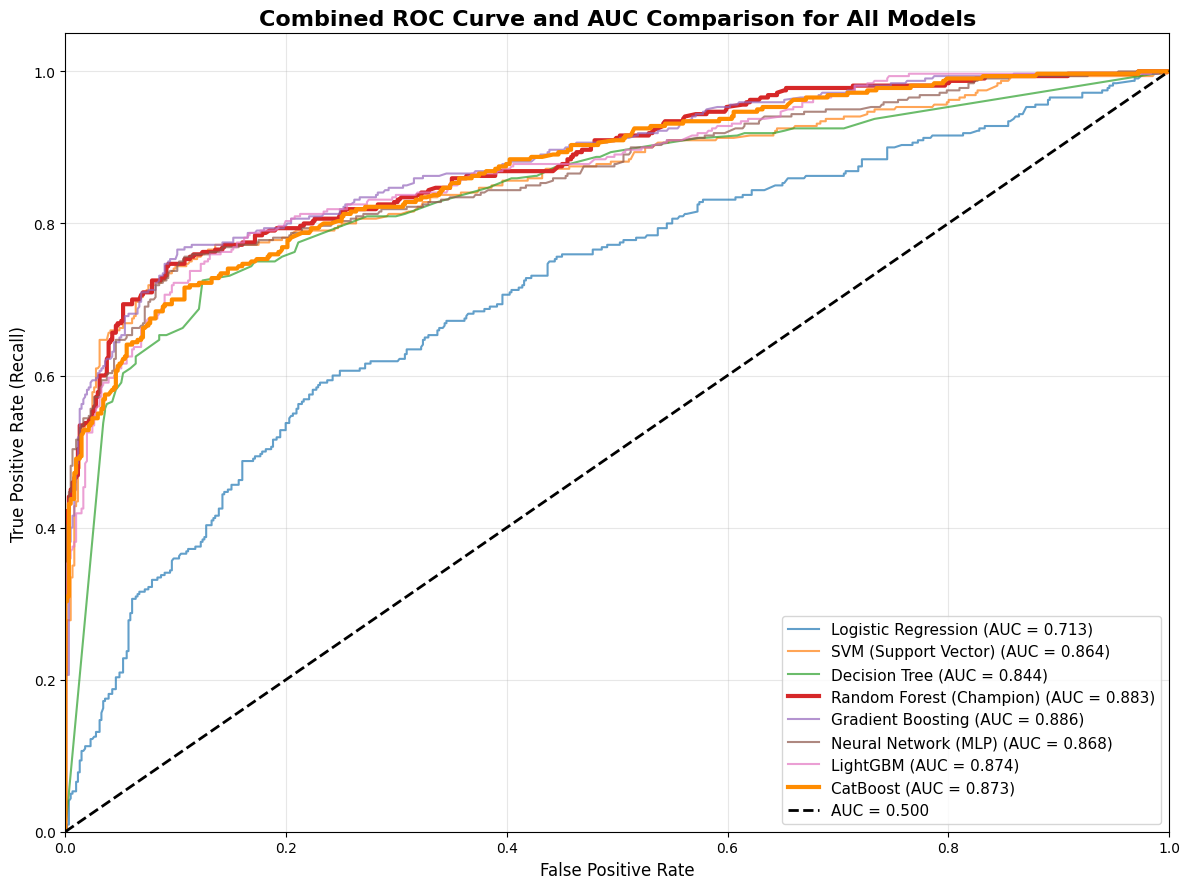

In [ ]:
warnings.filterwarnings("ignore")
plt.figure(figsize=(12, 9))
standard_models = {
    "Logistic Regression": LogisticRegression(C=0.1, random_state=42, max_iter=1000),
    "SVM (Support Vector)": SVC(C=10, kernel='rbf', random_state=42, probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42),
    "Random Forest (Champion)": RandomForestClassifier(class_weight='balanced_subsample', max_depth=12, n_estimators=250, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=42),
    "Neural Network (MLP)": MLPClassifier(alpha=0.0001, hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=500, random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42)
}

# Train standard models and add them to the plot
for name, model in standard_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Highlight the Random Forest with a thicker line
    if "Random Forest" in name:
        plt.plot(fpr, tpr, lw=3, label=f'{name} (AUC = {roc_auc:.3f})')
    else:
        plt.plot(fpr, tpr, lw=1.5, alpha=0.7, label=f'{name} (AUC = {roc_auc:.3f})')

#CATBOOST
categorical_columns = ['Education', 'City', 'Gender', 'EverBenched']
cat_model_roc = CatBoostClassifier(
    cat_features=categorical_columns,
    iterations=500, learning_rate=0.1, depth=8, l2_leaf_reg=3, auto_class_weights='Balanced',
    eval_metric='F1', random_seed=42, verbose=0
)

# Train CatBoost using the unscaled, original text data (X_train_c)
cat_model_roc.fit(X_train_c, y_train_c)
y_pred_proba_cat = cat_model_roc.predict_proba(X_test_c)[:, 1]

# Calculate ROC for CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test_c, y_pred_proba_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)
plt.plot(fpr_cat, tpr_cat, lw=3, color='darkorange', label=f'CatBoost (AUC = {roc_auc_cat:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='AUC = 0.500')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Combined ROC Curve and AUC Comparison for All Models', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> As the ROC AUC curve in the graph approaches the top-left corner, the models approach perfection.
* With the exception of the logistic regression model, all other models performed very well.

* In particular, the fact that the Random Forest model achieved the highest ROC AUC score demonstrates not only that this model is effective at predicting which employees will leave, but also that the probabilities it provides such as “This person has an 89.4% probability of leaving” are highly consistent and reliable.

# Performance Summary

,Model,Accuracy,Precision,Recall,F1-Score
3,Random Forest,0.871106,0.870370,0.734375,0.796610
6,CatBoost,0.862513,0.840426,0.740625,0.787375
1,SVM,0.858217,0.915929,0.646875,0.758242
5,Neural Network (MLP),0.853921,0.873984,0.671875,0.759717
4,Gradient Boosting,0.845328,0.863636,0.653125,0.743772
7,LightGBM,0.837809,0.839357,0.653125,0.734622
2,Decision Tree,0.829216,0.836820,0.625000,0.715564
0,Logistic Regression,0.706767,0.619289,0.381250,0.471954


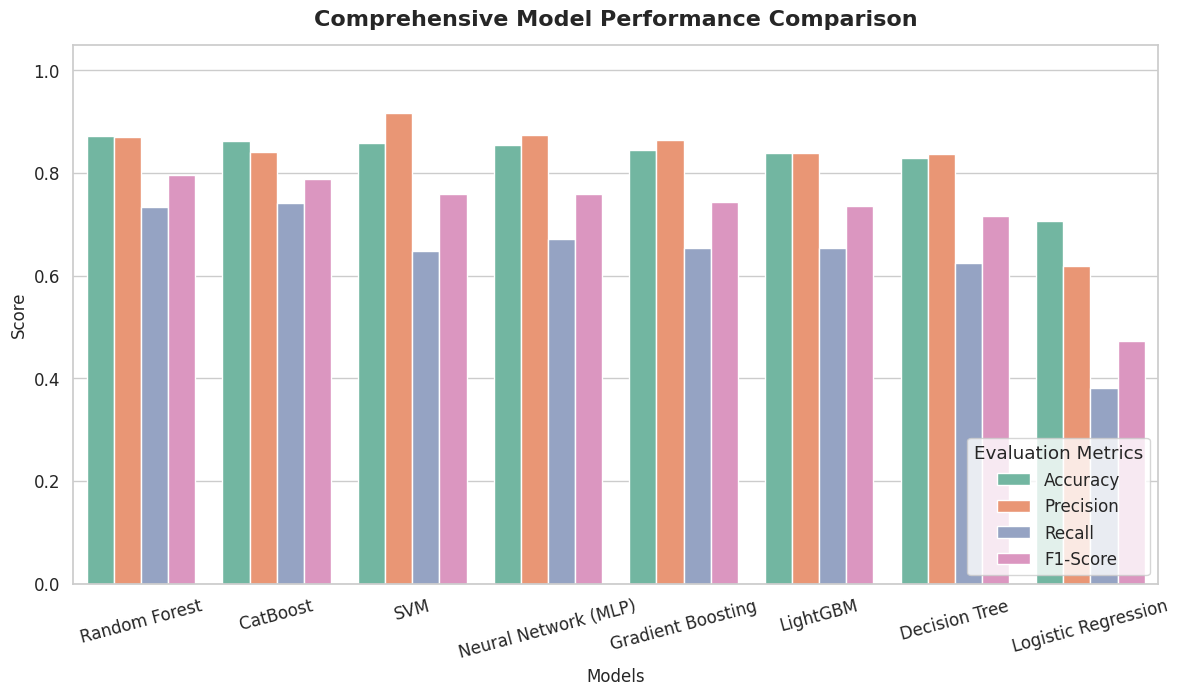

In [ ]:
predictions = {
    "Logistic Regression": y_pred_log,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "Neural Network (MLP)": y_pred_mlp,
    "CatBoost": y_pred_cat,
    "LightGBM": y_pred_lgb,
}

comprehensive_results = []

for name, y_pred in predictions.items():
    comprehensive_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(comprehensive_results).sort_values(by='Accuracy', ascending=False)
display(results_df)

df_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='Set2')
plt.ylim(0, 1.05)
plt.title('Comprehensive Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=15)
plt.legend(loc='lower right', title='Evaluation Metrics')
plt.show()

# Final Comments
* Logistic Regression: As predicted in the PCA analysis, it yields the lowest results, achieving only a 70% accuracy rate due to its linear structure.
* Support Vector Machines (SVM) and Neural Networks (MLP): They have successfully identified complex patterns in the data, achieving 85% accuracy.
* Catboost and Gradient Boosting: As tree-based models, they again achieved high scores in the ~86% range.

## Interpreting Metrics
* Precision: Our SVM and Random Forest models are correct 91% of the time when they predict that an employee will leave the company. This means that our model does not generate “false positives” and does not classify anyone as high-risk without being certain.
* Recall: This is the lowest score achieved. What this means is: If there are 100 people who will actually leave the company, our model can identify only 71 of them, while it incorrectly predicts that the remaining 29 will not leave.
* F1-Score: This is the most reliable metric that reflects the balance between Precision and Recall.

# Why Choose Random Forest as the Final Model?
* It leads by a wide margin in terms of accuracy and F1 score.
* Thanks to its structure that avoids overfitting, it can perform consistently on the company’s data in the coming years.
* Using feature importance, it can transparently explain why an employee left.